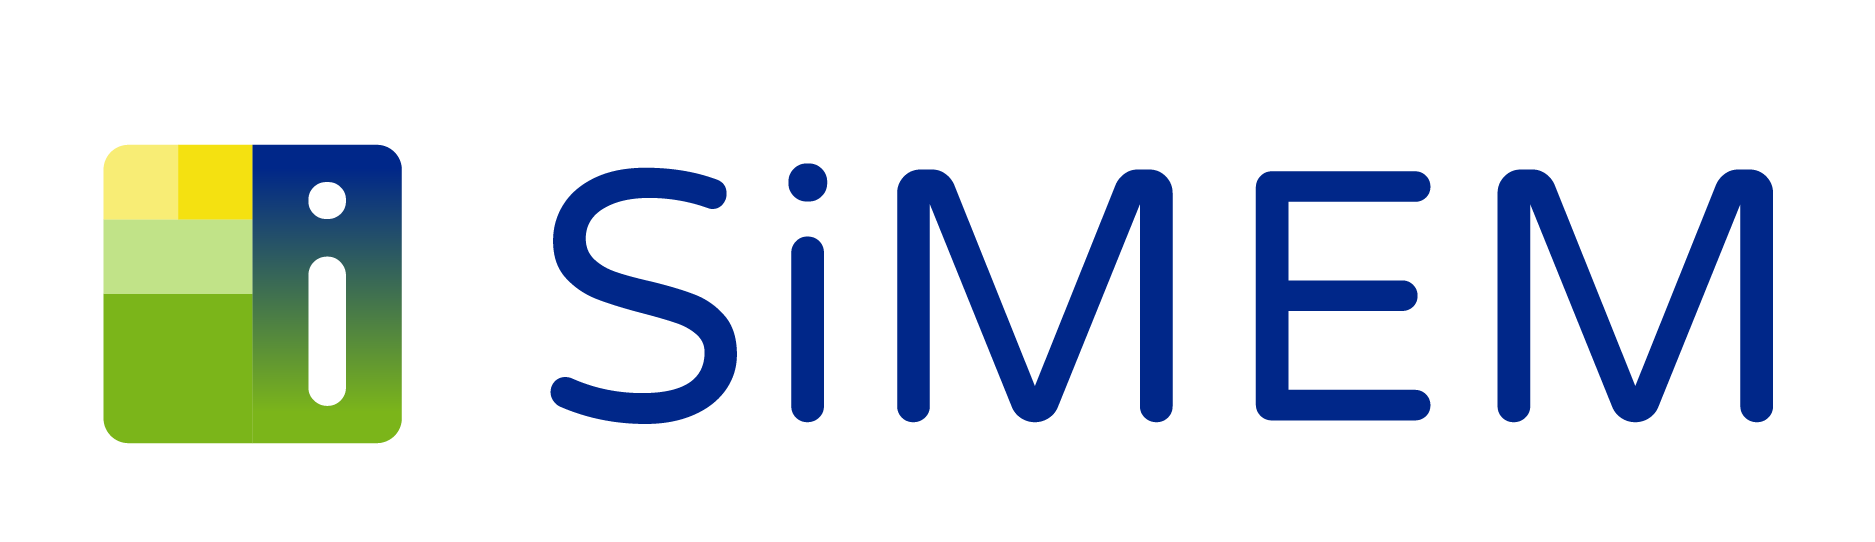

[SiMEM](https://www.simem.co/)

## Ejercicio de Validación Precio Promedio Ponderado de Bolsa (PPBO)

# Objetivos de este Notebook

* Explicar cómo se realiza la instalación e importación de la librería pydataxm desde la consola para su uso en ambientes locales
* Explicar cómo se pueden consultar los conjuntos de datos a través de la librería Pydataxm
* Explicar cómo realizar el procesamiento y manipulación de los datos consultados
* Explicar el análisis de los datos consultados para dar respuesta al caso propuesto
 
**Índice**

1. [Instalación de librerías](#section1)

2. [Importación de librerías](#section2)

3. [Consultar información de los conjuntos de datos](#section3)

4. [Manipulación de datos](#section4)

5. [Análisis para dar respuesta al caso de uso](#section5)

<a id='section1'></a>
# 1. Instalación de la librería
Ejecutar el siguiente comando en el CMD para instalar la librería de python.

In [1]:
# import sys
# !{sys.executable} -m pip install pydataxm

<a id='section2'></a>
# 2. Importación de librerías

In [1]:
# Importación de librerías necesarias para la consulta y análisis de datos
from pydataxm.pydatasimem import ReadSIMEM  # Importa clases para interactuar con datos del sistema SIMEM, utilizado para acceder a información energética en Colombia
import pandas as pd                         # Librería para manipulación y análisis de datos en estructuras tipo DataFrame, muy útil para limpiar, transformar y explorar datos
import numpy as np

<a id='section3'></a>
# 3. Consultar información de los conjuntos de datos
El método de extracción recibe los parámetros con los que se va a realizar la consulta. 
El datasetID para un conjunto particular se puede encontrar en el [catálogo de conjuntos de datos.](https://www.simem.co/pages/catalogodatos/51FC0A59-3A00-462C-B449-9CB8D5E007FB)  
Para este ejercicio de validación se utilizan los siguientes conjuntos de datos [Precio de bolsa horario](https://www.simem.co/datadetail/EC694552-8887-481D-8152-8055B36DB8A1) y [Magnitud energía en bolsa nacional a cargo](https://www.simem.co/datadetail/42edc929-6f52-4f19-8a12-53ce98e53272).

Se definen los parámetros de entrada y se crea el objeto ReadSIMEM() para realizar las consultas.

La función main contiene todo el proceso para transportar la información del dataset entre el rango de fechas solicitadas a un dataframe. Después de este paso, el proceso es de manipulación y visualización de datos.

In [ ]:
id_dataset_pbnal = 'EC6945'                                                     # ID del conjunto de datos a consultar
fecha_inicial = '2026-01-01'                                                    # Fecha de inicio del rango de consulta
fecha_final = '2026-01-10'                                                      # Fecha de fin del rango de consulta
simem_precio_bolsa = ReadSIMEM(id_dataset_pbnal, fecha_inicial, fecha_final)    # Instancia de la clase ReadSIMEM con los parámetros definidos
df_pbnal = simem_precio_bolsa.main()                                            # Ejecución del método principal para obtener los datos en un DataFrame
display(df_pbnal.head(20))                                                      # Visualización de las primeras 20 filas del DataFrame

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Precio de bolsa horario"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.000993967056274414
Extraccion de registros: 1.4210824966430664
End of data extracting process
****************************************************************************************************


,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
0,PB_Int,2026-01-10 03:00:00,PT1H,COP/kWh,TX1,160.0000
1,PB_Tie,2026-01-10 09:00:00,PT1H,COP/kWh,TX1,135.0000
2,PB_Tie,2026-01-10 10:00:00,PT1H,COP/kWh,TX2,135.0000
3,PB_Tie,2026-01-10 05:00:00,PT1H,COP/kWh,TX2,160.0000
4,PB_Tie,2026-01-10 11:00:00,PT1H,COP/kWh,TX1,135.0000
5,PB_Tie,2026-01-10 18:00:00,PT1H,COP/kWh,TX2,260.0000
6,PB_Tie,2026-01-10 20:00:00,PT1H,COP/kWh,TX2,260.0000
7,PB_Nal,2026-01-10 03:00:00,PT1H,COP/kWh,TX1,162.1338
8,PB_Int,2026-01-10 17:00:00,PT1H,COP/kWh,TX2,260.0000
9,PB_Nal,2026-01-10 14:00:00,PT1H,COP/kWh,TX1,173.1338


In [ ]:
id_dataset_comprasb = '42EDC9'                                                      # ID del conjunto de datos a consultar
fecha_inicial = '2026-01-01'                                                        # Fecha de inicio del rango de consulta
fecha_final = '2026-01-10'                                                          # Fecha de fin del rango de consulta
simem_proyecciones = ReadSIMEM(id_dataset_comprasb, fecha_inicial, fecha_final)     # Instancia de la clase ReadSIMEM con los parámetros definidos
df_compras_bolsa = simem_proyecciones.main()                                        # Ejecución del método principal para obtener los datos en un DataFrame
display(df_compras_bolsa.head(20))                                                  # Visualización de las primeras 20 filas del DataFrame

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Magnitud energía en bolsa nacional a cargo"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0009987354278564453
The object has been initialized with the dataset: "Magnitud energía en bolsa nacional a cargo"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0009987354278564453
Extraccion de registros: 5.029259920120239
End of data extracting process
****************************************************************************************************
Extraccion de registros: 5.029259920120239
End of data extracting process
****************************************************************************************************


,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,CodigoSICAgente,Version,Valor
0,MgCB,2026-01-10 15:00:00,PT1H,kWh,DUCC,TX2,0.00
1,MgCB,2026-01-10 08:00:00,PT1H,kWh,GSAC,TX2,17.61
2,MgCB,2026-01-10 02:00:00,PT1H,kWh,CALG,TX2,0.00
3,MgCB,2026-01-10 15:00:00,PT1H,kWh,CTCG,TX2,0.00
4,MgCB,2026-01-10 10:00:00,PT1H,kWh,NRCG,TX2,3456.65
5,MgCB,2026-01-10 20:00:00,PT1H,kWh,HZEG,TX2,0.00
6,MgCB,2026-01-10 12:00:00,PT1H,kWh,ERRG,TX2,136.31
7,MgCB,2026-01-10 18:00:00,PT1H,kWh,SPKG,TX2,0.00
8,MgCB,2026-01-10 13:00:00,PT1H,kWh,CETC,TX2,0.00
9,MgCB,2026-01-10 04:00:00,PT1H,kWh,GNSG,TX2,49.91


In [ ]:
id_dataset_ppbo = '96D56E'                                                      # ID del conjunto de datos a consultar
fecha_inicial = '2026-01-01'                                                    # Fecha de inicio del rango de consulta
fecha_final = '2026-01-10'                                                      # Fecha de fin del rango de consulta
simem_ppbo = ReadSIMEM(id_dataset_ppbo, fecha_inicial, fecha_final)             # Instancia de la clase ReadSIMEM con los parámetros definidos
df_ppbo_simem = simem_ppbo.main()                                               # Ejecución del método principal para obtener los datos en un DataFrame
display(df_ppbo_simem.head(20))  

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Precio de bolsa ponderado"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0009922981262207031
The object has been initialized with the dataset: "Precio de bolsa ponderado"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0009922981262207031
Extraccion de registros: 3.029754161834717
End of data extracting process
****************************************************************************************************
Extraccion de registros: 3.029754161834717
End of data extracting process
****************************************************************************************************


,CodigoVariable,Fecha,CodigoDuracion,UnidadMedida,Version,Valor
0,PPBO,2026-01-10,P1D,COP/kWh,TX2,190.7563
1,PPBOGReal,2026-01-10,P1D,COP/kWh,TX2,192.5697
2,PPBOGReal,2026-01-10,P1D,COP/kWh,TX1,193.2427
3,PPBO,2026-01-09,P1D,COP/kWh,TX2,190.9496
4,PPBOGReal,2026-01-09,P1D,COP/kWh,TX2,196.7627
5,PPBOGReal,2026-01-09,P1D,COP/kWh,TX1,197.5877
6,PPBO,2026-01-08,P1D,COP/kWh,TX2,189.8645
7,PPBOGReal,2026-01-08,P1D,COP/kWh,TX2,196.0611
8,PPBOGReal,2026-01-08,P1D,COP/kWh,TX1,198.6197
9,PPBO,2026-01-07,P1D,COP/kWh,TX2,266.0842


<a id='section4'></a>
# 4. Manipulación de datos
Los siguientes pasos corresponden a las actividades de manipulación y preparación de los datos que son relevantes para el análisis. 

Los dataframes se filtarán para tener los datos necesarios para el cálculo, inicialmente seleccionando la última información publicada, luego las variables se ajustaran a la misma unidad de medida y finalmente se tomaran las columnas necesarias.

In [ ]:
# Extracción del DataFrame con el precio de bolsa nacional y la version TX2 de la liquidación
df_precio_bolsa_nacional = df_pbnal.query("CodigoVariable == 'PB_Nal' and Version == 'TX2'")[['FechaHora', 'Version', 'Valor']]
df_precio_bolsa_nacional

,FechaHora,Version,Valor
10,2026-01-10 06:00:00,TX2,173.1593
12,2026-01-10 03:00:00,TX2,162.1593
24,2026-01-10 20:00:00,TX2,273.1593
35,2026-01-10 05:00:00,TX2,173.1593
37,2026-01-10 10:00:00,TX2,110.2413
...,...,...,...
1362,2026-01-01 09:00:00,TX2,225.6460
1366,2026-01-01 06:00:00,TX2,292.5180
1427,2026-01-01 12:00:00,TX2,269.1060
1429,2026-01-01 08:00:00,TX2,269.1060


In [ ]:
# Sumatoria diaria de las compras en bolsa por versión TX2
df_compras_diarias = (                                                                                # Se agrupa por la información
    df_compras_bolsa
        .groupby(['FechaHora', 'Version'], as_index=False)
        .agg({'Valor': 'sum'})
)

df_compras_diarias.query("Version == 'TX2'")[['FechaHora', 'Version', 'Valor']]

,FechaHora,Version,Valor
0,2026-01-01 00:00:00,TX2,3152957.33
1,2026-01-01 01:00:00,TX2,3154692.34
2,2026-01-01 02:00:00,TX2,2690186.95
3,2026-01-01 03:00:00,TX2,2567799.55
4,2026-01-01 04:00:00,TX2,2427928.23
...,...,...,...
235,2026-01-10 19:00:00,TX2,2617093.01
236,2026-01-10 20:00:00,TX2,2499892.87
237,2026-01-10 21:00:00,TX2,2446803.03
238,2026-01-10 22:00:00,TX2,2526159.01


In [ ]:
# PPBO SIMEM versión TX2
df_ppbo_simem = df_ppbo_simem.query("CodigoVariable == 'PPBO' and Version == 'TX2'")[['Fecha', 'Version', 'Valor']]
df_ppbo_simem['Fecha'] = pd.to_datetime(df_ppbo_simem['Fecha']).dt.date
df_ppbo_simem

,Fecha,Version,Valor
0,2026-01-10,TX2,190.7563
3,2026-01-09,TX2,190.9496
6,2026-01-08,TX2,189.8645
9,2026-01-07,TX2,266.0842
12,2026-01-06,TX2,314.0686
15,2026-01-05,TX2,319.6662
18,2026-01-04,TX2,298.9608
21,2026-01-03,TX2,335.9258
24,2026-01-02,TX2,331.1803
27,2026-01-01,TX2,291.7816


<a id='section5'></a>
# 5. Respuesta al caso

Con estos insumos, se procede a calular el Precio promedio ponderado por compras en bolsa (PPBO)

In [ ]:
# Cálculo del producto del precio de bolsa nacional por las compras diarias en bolsa para cada hora
df_compras_por_precio = df_compras_diarias.merge(df_precio_bolsa_nacional, on=['FechaHora', 'Version'], suffixes=('_Compra', '_PB_Nal'))    
df_compras_por_precio['PbhxCb'] = df_compras_por_precio.apply(lambda row: row['Valor_Compra'] * row['Valor_PB_Nal'], axis=1)
df_compras_por_precio['Fecha'] = pd.to_datetime(df_compras_por_precio['FechaHora']).dt.date
df_compras_por_precio

,FechaHora,Version,Valor_Compra,Valor_PB_Nal,PbhxCb,Fecha
0,2026-01-01 00:00:00,TX2,3152957.33,324.1060,1.021892e+09,2026-01-01
1,2026-01-01 01:00:00,TX2,3154692.34,304.1060,9.593609e+08,2026-01-01
2,2026-01-01 02:00:00,TX2,2690186.95,292.5180,7.869281e+08,2026-01-01
3,2026-01-01 03:00:00,TX2,2567799.55,292.5180,7.511276e+08,2026-01-01
4,2026-01-01 04:00:00,TX2,2427928.23,292.5180,7.102127e+08,2026-01-01
...,...,...,...,...,...,...
235,2026-01-10 19:00:00,TX2,2617093.01,273.1593,7.148833e+08,2026-01-10
236,2026-01-10 20:00:00,TX2,2499892.87,273.1593,6.828690e+08,2026-01-10
237,2026-01-10 21:00:00,TX2,2446803.03,273.1593,6.683670e+08,2026-01-10
238,2026-01-10 22:00:00,TX2,2526159.01,273.1593,6.900438e+08,2026-01-10


Cálculo del numerador del PPBO, que corresponde a la sumatoria del producto del precio de bolsa nacional por las compras diarias en bolsa

In [ ]:
df_numerador = df_compras_por_precio.groupby(['Fecha', 'Version'], as_index=False).agg({'PbhxCb': 'sum'})
df_numerador


,Fecha,Version,PbhxCb
0,2026-01-01,TX2,1.722533e+10
1,2026-01-02,TX2,1.755801e+10
2,2026-01-03,TX2,1.651148e+10
3,2026-01-04,TX2,1.251242e+10
4,2026-01-05,TX2,1.794720e+10
5,2026-01-06,TX2,1.482213e+10
6,2026-01-07,TX2,1.605320e+10
7,2026-01-08,TX2,1.121885e+10
8,2026-01-09,TX2,1.188710e+10
9,2026-01-10,TX2,1.190444e+10


Cálculo del denominador del PPBO, que corresponde a la sumatoria de las compras diarias en bolsa

In [ ]:
df_denominador = df_compras_por_precio.groupby(['Fecha', 'Version'], as_index=False).agg({'Valor_Compra': 'sum'})
df_denominador

,Fecha,Version,Valor_Compra
0,2026-01-01,TX2,59035000.82
1,2026-01-02,TX2,53016465.37
2,2026-01-03,TX2,49152172.93
3,2026-01-04,TX2,41853049.58
4,2026-01-05,TX2,56143552.42
5,2026-01-06,TX2,47193918.68
6,2026-01-07,TX2,60331293.73
7,2026-01-08,TX2,59088707.57
8,2026-01-09,TX2,62252570.96
9,2026-01-10,TX2,62406568.29


Se procede a calcular el PPBO y se compara con el dato publicado en SIMEM

In [ ]:
# Cálculo del PPBO
df_ppbo = df_numerador.merge(df_denominador, on=['Fecha', 'Version'])
df_ppbo = df_ppbo.merge(df_ppbo_simem, on=['Fecha', 'Version'])
df_ppbo.rename(columns={'Valor': 'PPBO_SIMEM'}, inplace=True)
df_ppbo['PPBO'] = df_ppbo.apply(lambda row: row['PbhxCb'] / row['Valor_Compra'], axis=1).round(4)
df_ppbo

,Fecha,Version,PbhxCb,Valor_Compra,PPBO_SIMEM,PPBO
0,2026-01-01,TX2,1.722533e+10,59035000.82,291.7816,291.7816
1,2026-01-02,TX2,1.755801e+10,53016465.37,331.1803,331.1803
2,2026-01-03,TX2,1.651148e+10,49152172.93,335.9258,335.9258
3,2026-01-04,TX2,1.251242e+10,41853049.58,298.9608,298.9608
4,2026-01-05,TX2,1.794720e+10,56143552.42,319.6662,319.6662
5,2026-01-06,TX2,1.482213e+10,47193918.68,314.0686,314.0686
6,2026-01-07,TX2,1.605320e+10,60331293.73,266.0842,266.0842
7,2026-01-08,TX2,1.121885e+10,59088707.57,189.8645,189.8645
8,2026-01-09,TX2,1.188710e+10,62252570.96,190.9496,190.9496
9,2026-01-10,TX2,1.190444e+10,62406568.29,190.7563,190.7562
